In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving complaints.csv to complaints.csv
Saving network_qos.csv to network_qos.csv
Saving revenue.csv to revenue.csv
Saving usage.csv to usage.csv


In [4]:
qos = pd.read_csv("/content/network_qos.csv")
usage = pd.read_csv("/content/usage.csv")
revenue = pd.read_csv("/content/revenue.csv")
complaints = pd.read_csv("/content/complaints.csv")

qos.head()

,region,signal_strength,latency_ms,throughput_mbps,outages
0,Delhi,-70,25,35,2
1,Mumbai,-65,20,42,1
2,Chennai,-75,28,32,3
3,Kolkata,-72,30,30,2
4,Hyderabad,-68,22,40,1


In [5]:
#Data Integration(ETL)
df = (qos
      .merge(usage, on="region", how="left")
      .merge(revenue, on="region", how="left")
      .merge(complaints, on="region", how="left"))

In [6]:
#Data cleaning
df.fillna({
    "signal_strength": df["signal_strength"].mean(),
    "latency_ms": df["latency_ms"].mean(),
    "throughput_mbps": df["throughput_mbps"].mean(),
    "complaints": 0
}, inplace=True)

df

,region,signal_strength,latency_ms,throughput_mbps,outages,data_gb,call_minutes,dropped_calls,ARPU,customer_count,complaints,month
0,Delhi,-70,25,35,2,250,300000,100,320,56000,110,Aug
1,Mumbai,-65,20,42,1,270,290000,90,400,64000,95,Aug
2,Chennai,-75,28,32,3,220,270000,120,280,49000,140,Aug
3,Kolkata,-72,30,30,2,180,260000,130,250,45000,150,Aug
4,Hyderabad,-68,22,40,1,260,275000,110,380,51000,100,Aug


In [7]:
df.to_csv("network_master.csv", index=False)
print("Clean dataset saved!")

Clean dataset saved!


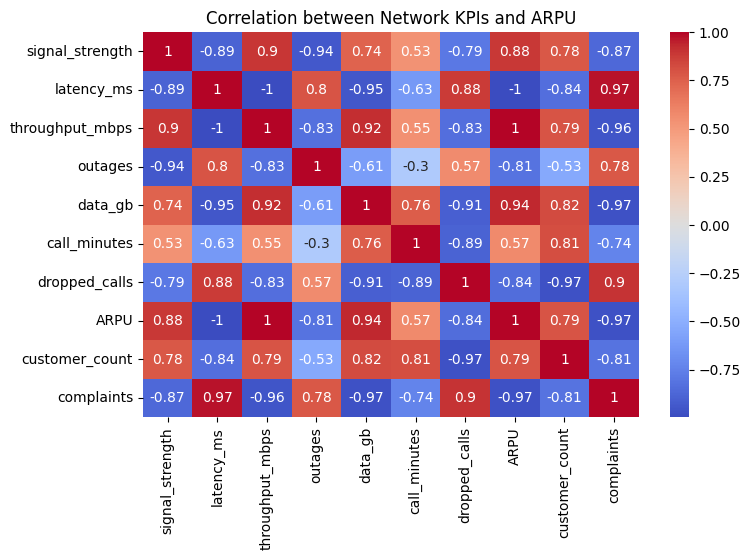

In [8]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation between Network KPIs and ARPU")
plt.show()

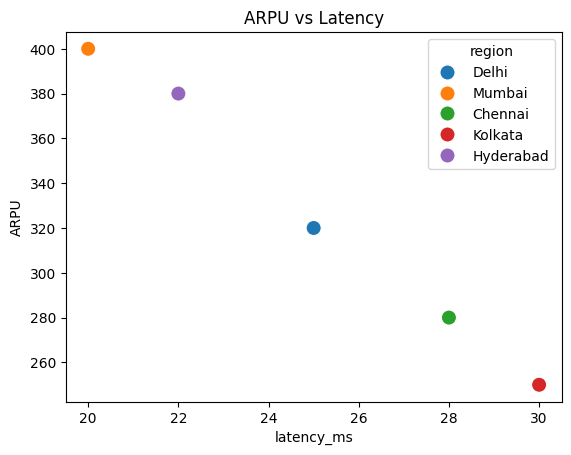

In [9]:
#ARPU vs Latency
sns.scatterplot(x="latency_ms", y="ARPU", data=df, hue="region", s=120)
plt.title("ARPU vs Latency")
plt.show()

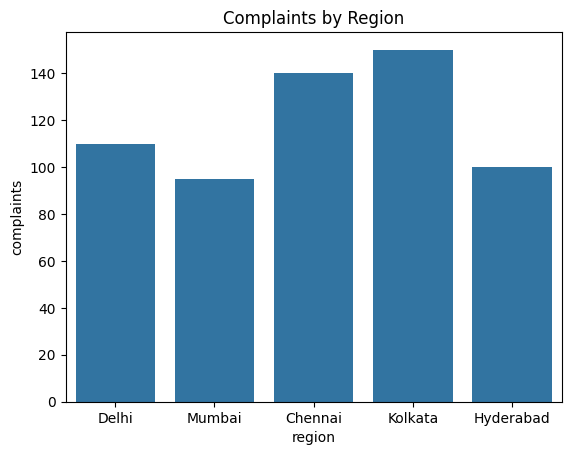

In [10]:
#Complaints per Region
sns.barplot(x="region", y="complaints", data=df)
plt.title("Complaints by Region")
plt.show()

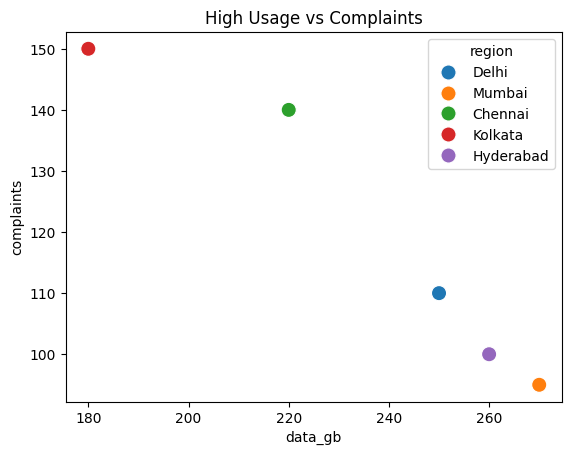

In [11]:
#High Usage vs Complaints
sns.scatterplot(x="data_gb", y="complaints", data=df, hue="region", s=120)
plt.title("High Usage vs Complaints")
plt.show()

In [12]:
#Predictive Modeling
from sklearn.model_selection import train_test_split

X = df[["latency_ms","throughput_mbps","complaints","data_gb","outages"]]
y = df["ARPU"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R²:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

R²: -25.699353776885893
MAE: 51.41069589970323


In [14]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=3)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R²:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))

R²: -49.0
MAE: 70.0


In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R2": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt)],
    "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_dt)]
})

results

,Model,R2,MAE
0,Linear Regression,-25.699354,51.410696
1,Decision Tree,-49.000000,70.000000


In [16]:
#Identify High-Risk Regions (Classification)
df["low_revenue_flag"] = np.where(df["ARPU"] < df["ARPU"].median(), 1, 0)

In [17]:
#Train Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[["latency_ms","throughput_mbps","complaints","outages","data_gb"]]
y = df["low_revenue_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [18]:
df["risk_prediction"] = clf.predict(df[X.columns])
df.to_csv("predictions.csv", index=False)